# Model Evaluation & Comparison

Reads pre-computed metrics and best-variant predictions from every model notebook and
produces a single cross-model leaderboard + the consolidated DM-vs-Drift battery. Run after all model notebooks have been executed (their CSVs must be fresh).

**Models covered** (all forecast the weekly W-FRI silver log-return): ARIMA/ARIMAX, VAR,
Random Forest, XGBoost, LSTM, MIDAS — plus the daily-input siblings LSTM (daily) and
MIDAS (daily).

**Primary metrics**: RMSE / MAE (magnitude — the load-bearing test is each notebook's
DM-vs-Drift floor). **Secondary**: WDA / DA (directional lens).
Definitions: `01_arima` §5 / `weekly/notes.md`.

In [1]:
import sys, os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats

plt.rcParams['figure.dpi'] = 120
sns.set_theme(style='whitegrid')

DATA = '../data/processed/'
sys.path.append('../src')
from eval_utils import diebold_mariano, pesaran_timmermann, oos_r2, PERIODS


## 1. Load & harmonise metrics

Pure ARIMA is folded into the **Drift floor**, not listed as a separate model: expanding
ARIMA(0,0,0) *is* the drift, and the rolling variant's only edge is a 2025 regime tilt
(insignificant, reverses ex-2025 — see `01_arima` §3.1 / §8c). The ARIMA family is therefore
represented by **ARIMAX** (its public-info rungs); the Drift benchmark row stands in for pure ARIMA.

In [2]:
# file → model family (all forecast the weekly W-FRI silver return)
metrics_map = {
    'metrics_arima.csv':              'ARIMAX',   # pure ARIMA collapsed into Drift (see note / drop below)
    'metrics_var.csv':                'VAR',
    'metrics_rf.csv':                 'Random Forest',
    'metrics_xgboost.csv':            'XGBoost',
    'metrics_lstm_weekly.csv':        'LSTM',
    'metrics_midas.csv':              'MIDAS',
    'metrics_midas_daily_weekly.csv': 'MIDAS (daily)',
    'metrics_lstm_daily_weekly.csv':  'LSTM (daily)',
}

frames = []
for fname, family in metrics_map.items():
    df = pd.read_csv(DATA + fname)  # a missing file means stale outputs — error loudly
    df = df.rename(columns={'dir_acc': 'da', 'oos_r2': 'r2_os'})
    if fname.startswith('metrics_midas'):
        df['r2_os'] *= 100  # MIDAS saves OOS R² as a fraction; the others are already ×100
    df['family'] = family
    frames.append(df)

all_metrics = pd.concat(frames, ignore_index=True)

# Collapse pure ARIMA into the Drift floor: expanding ARIMA(0,0,0) IS the drift (a duplicate of
# the benchmark row below) and 'ARIMA rolling (100w)' adds only a 2025 regime tilt — DM p=0.74,
# reverses ex-2025 (01_arima §3.1/§8c), not predictability. Drop both pure-ARIMA competitor rows;
# the Drift benchmark row stands in for them and metrics_arima.csv keeps only its ARIMAX rungs.
# (The rows are 'ARIMA expanding' / 'ARIMA rolling (100w)' — note the trailing space, so 'ARIMAX…'
# is untouched.)
all_metrics = all_metrics[~all_metrics['model'].str.startswith('ARIMA ')].reset_index(drop=True)

# Convert log-return errors to percentage points for interpretability
# RMSE=0.052 log-return → 5.2% per week
all_metrics['rmse'] *= 100
all_metrics['mae']  *= 100

# Flag the two benchmark rows every metrics file carries: Naive (t-1) and the Drift
# EMH floor. Drift's sign is constant-positive, so its WDA doubles as the always-up line.
all_metrics['is_baseline'] = all_metrics['model'].str.startswith(('Naive', 'Drift'))

print(f'Loaded {len(all_metrics)} rows across {all_metrics["family"].nunique()} model families')
all_metrics.head(10)

Loaded 360 rows across 8 model families


,model,rmse,mae,r2_os,da,wda,family,rmse_std,mae_std,r2_os_std,dir_acc_std,wda_std,is_baseline
0,Naive (t-1 week),7.594131,5.396601,-112.857285,0.491329,0.489862,ARIMAX,NaN,NaN,NaN,NaN,NaN,True
1,Drift (prevailing mean),5.190225,3.713512,0.000000,0.557471,0.587779,ARIMAX,NaN,NaN,NaN,NaN,NaN,True
2,ARIMAX rolling (100w),5.322612,3.764998,-5.166460,0.522989,0.482664,ARIMAX,NaN,NaN,NaN,NaN,NaN,False
3,ARIMAX expanding,5.219617,3.683489,-1.135784,0.568966,0.554856,ARIMAX,NaN,NaN,NaN,NaN,NaN,False
4,ARIMAX+GS rolling (100w),5.450048,3.767495,-10.262602,0.580460,0.573317,ARIMAX,NaN,NaN,NaN,NaN,NaN,False
5,ARIMAX+GS expanding,5.200098,3.670310,-0.380822,0.597701,0.605666,ARIMAX,NaN,NaN,NaN,NaN,NaN,False
6,ARIMAX+FRED_daily rolling (100w),5.370690,3.786585,-7.074915,0.557471,0.511996,ARIMAX,NaN,NaN,NaN,NaN,NaN,False
7,ARIMAX+FRED_daily expanding,5.236005,3.694860,-1.771855,0.580460,0.521206,ARIMAX,NaN,NaN,NaN,NaN,NaN,False
8,ARIMAX+COT rolling (100w),5.468442,3.831387,-11.008131,0.586207,0.589254,ARIMAX,NaN,NaN,NaN,NaN,NaN,False
9,ARIMAX+COT expanding,5.217645,3.693639,-1.059388,0.563218,0.556607,ARIMAX,NaN,NaN,NaN,NaN,NaN,False


## 2. Full leaderboard

Best variant per model family, selected two ways (mirroring the dual RMSE+WDA selection
in the model notebooks): **by RMSE** (primary, magnitude) and **by WDA** (secondary,
directional). Naive and Drift benchmark rows appended to each table — the Drift row is
the EMH floor and the always-up directional line.

In [3]:
models_only = all_metrics[~all_metrics['is_baseline']].copy()

# One benchmark row per name — values are identical across files up to float noise
baselines = all_metrics[all_metrics['is_baseline']].drop_duplicates(subset='model').copy()
baselines['family'] = '── Benchmark ──'

COLS    = ['family', 'model', 'rmse', 'mae', 'r2_os', 'da', 'wda']
RENAMES = {'family': 'Model', 'model': 'Best variant', 'rmse': 'RMSE (%)',
           'mae': 'MAE (%)', 'r2_os': 'R²_OS (%)', 'da': 'DA', 'wda': 'WDA'}

def leaderboard(by, ascending, title):
    """Best variant per family by `by`, benchmarks appended; returns the best frame."""
    best = (
        models_only
        .sort_values(by, ascending=ascending)
        .groupby('family', sort=False)
        .first()
        .reset_index()
        .sort_values(by, ascending=ascending)
    )
    table = pd.concat([best[COLS], baselines[COLS]], ignore_index=True).rename(columns=RENAMES)
    table[['RMSE (%)', 'MAE (%)', 'R²_OS (%)']] = table[['RMSE (%)', 'MAE (%)', 'R²_OS (%)']].round(2)
    table[['DA', 'WDA']] = table[['DA', 'WDA']].round(3)
    print(f'\n── {title} ──')
    print(table.to_string(index=False))
    return best

best_rmse = leaderboard('rmse', True,  'Best by RMSE (primary)')
best_wda  = leaderboard('wda',  False, 'Best by WDA (secondary, directional)')


── Best by RMSE (primary) ──
          Model                  Best variant  RMSE (%)  MAE (%)  R²_OS (%)    DA   WDA
        XGBoost        EXOG+ALLPaid expanding      5.14     3.69       1.84 0.540 0.574
  MIDAS (daily)        EXOG-d+GS_HF expanding      5.14     3.68       1.78 0.586 0.607
   LSTM (daily)  LSTM-d-EXOG-GS-SENTIMENTPAID      5.16     3.70       1.27 0.561 0.568
  Random Forest      EXOG+News rolling (100w)      5.16     3.72       0.98 0.517 0.560
           LSTM             LSTM-EXOG-ALLPAID      5.17     3.71       0.59 0.556 0.563
            VAR   EXOG+GS+Sentiment expanding      5.18     3.66       0.41 0.603 0.594
         ARIMAX ARIMAX+GS+Sentiment expanding      5.18     3.65       0.23 0.609 0.588
          MIDAS                EXOG expanding      5.21     3.71      -0.68 0.546 0.507
── Benchmark ──              Naive (t-1 week)      7.59     5.40    -112.86 0.491 0.490
── Benchmark ──       Drift (prevailing mean)      5.19     3.71       0.00 0.557 0.588

─

## 3. RMSE / MAE comparison — best variant per family

Primary (magnitude) lens: each family's RMSE-best variant against the **Drift floor**
(green = below Drift's RMSE, red = above). Descriptive only — significance is each
notebook's DM-vs-Drift test.

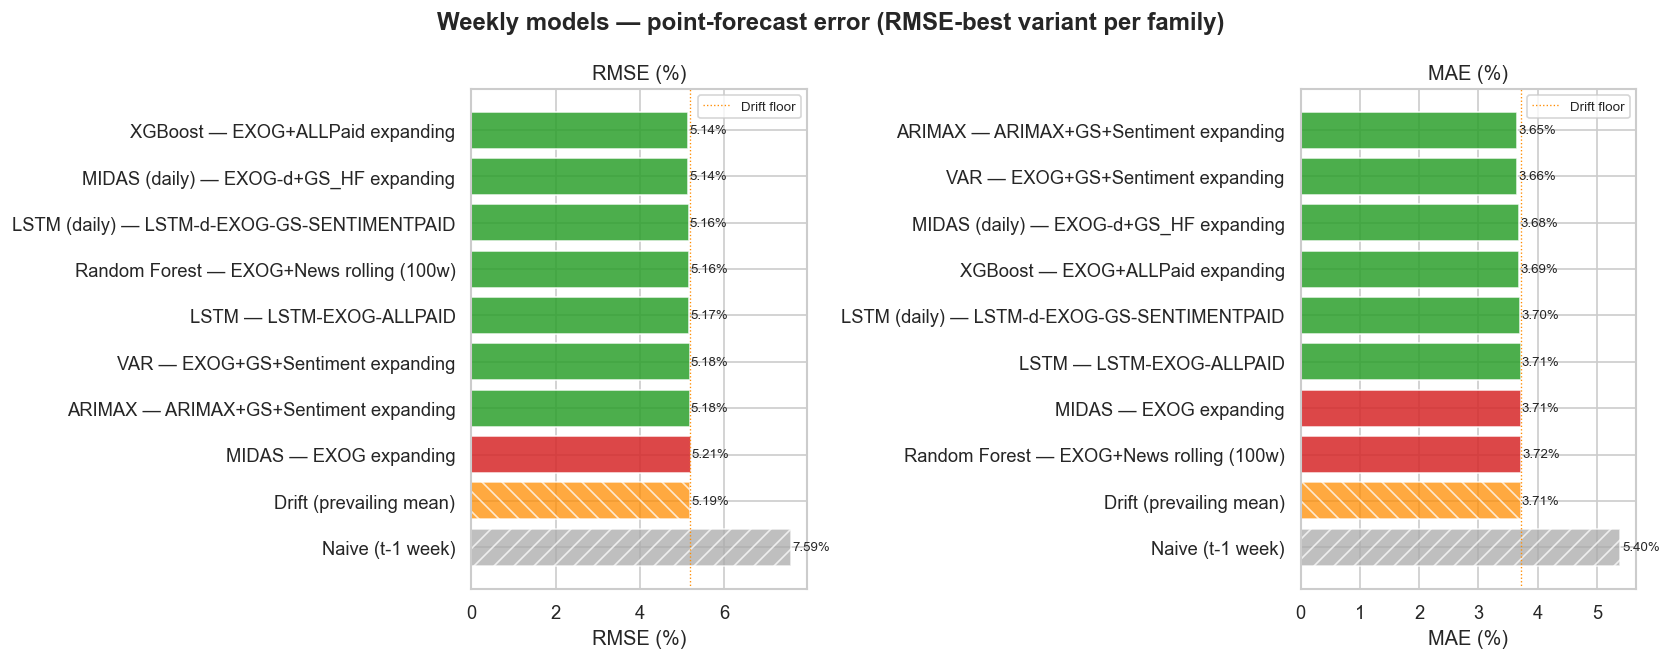

In [4]:
naive = baselines[baselines['model'].str.startswith('Naive')].iloc[0]
drift = baselines[baselines['model'].str.startswith('Drift')].iloc[0]

plot_rmse = best_rmse.copy()
plot_rmse['label'] = plot_rmse['family'] + ' — ' + plot_rmse['model']

fig, axes = plt.subplots(1, 2, figsize=(14, max(4, len(plot_rmse) * 0.45 + 2)))
fig.suptitle('Weekly models — point-forecast error (RMSE-best variant per family)',
             fontweight='bold')

for ax, metric, label in zip(axes, ['rmse', 'mae'], ['RMSE (%)', 'MAE (%)']):
    # benchmark bars at the bottom (grey = naive, orange = drift)
    ax.barh(naive['model'], naive[metric], color='#aaaaaa', alpha=0.75, hatch='//')
    ax.barh(drift['model'], drift[metric], color='darkorange', alpha=0.75, hatch='\\\\')

    df = plot_rmse.sort_values(metric, ascending=False)  # best (lowest) ends up on top
    colors = ['#2ca02c' if v < drift[metric] else '#d62728' for v in df[metric]]
    ax.barh(df['label'], df[metric], color=colors, alpha=0.85)

    ax.axvline(drift[metric], color='darkorange', lw=0.8, ls=':', label='Drift floor')
    ax.set_xlabel(label)
    ax.set_title(label)
    ax.legend(fontsize=8)
    for v, name in zip(df[metric], df['label']):
        ax.text(v * 1.005, name, f'{v:.2f}%', va='center', fontsize=8)
    for row in (naive, drift):
        ax.text(row[metric] * 1.005, row['model'], f'{row[metric]:.2f}%', va='center', fontsize=8)

plt.tight_layout()
fig.savefig('../images/returns_rmse.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. WDA / DA comparison — best variant per family

Secondary (directional) lens: each family's WDA-best variant. The Drift bar **is** the
always-up line (its sign is constant-positive), so green = beats always-up, red = doesn't.
Directional significance is the per-notebook Pesaran-Timmermann test.

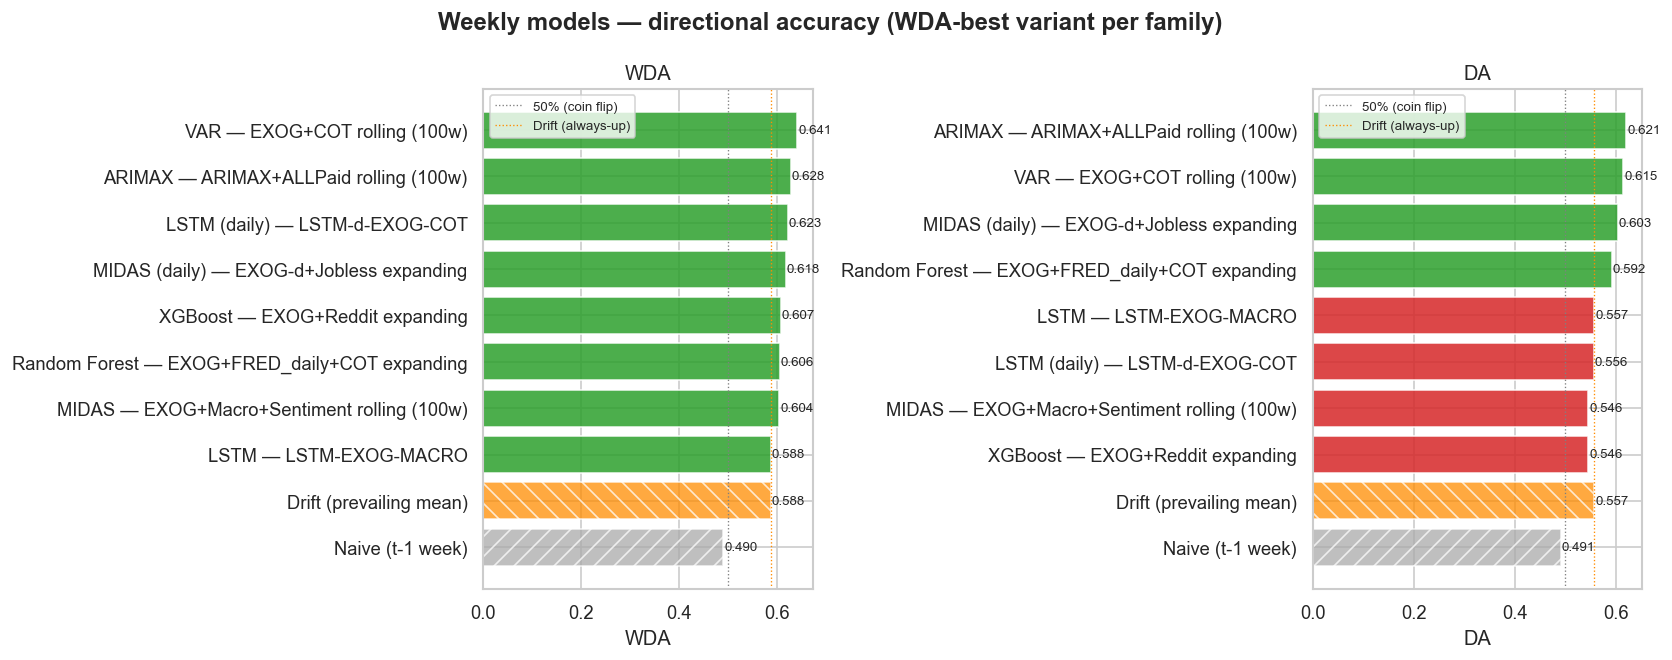

In [5]:
plot_wda = best_wda.copy()
plot_wda['label'] = plot_wda['family'] + ' — ' + plot_wda['model']

fig, axes = plt.subplots(1, 2, figsize=(14, max(4, len(plot_wda) * 0.45 + 2)))
fig.suptitle('Weekly models — directional accuracy (WDA-best variant per family)',
             fontweight='bold')

for ax, metric, title in zip(axes, ['wda', 'da'], ['WDA', 'DA']):
    # benchmark bars at the bottom (grey = naive, orange = drift/always-up)
    ax.barh(naive['model'], naive[metric], color='#aaaaaa', alpha=0.75, hatch='//')
    ax.barh(drift['model'], drift[metric], color='darkorange', alpha=0.75, hatch='\\\\')

    df = plot_wda.sort_values(metric, ascending=True)  # best (highest) ends up on top
    colors = ['#2ca02c' if v > drift[metric] else '#d62728' for v in df[metric]]
    ax.barh(df['label'], df[metric], color=colors, alpha=0.85)

    ax.axvline(0.5, color='grey', lw=0.8, ls=':', label='50% (coin flip)')
    ax.axvline(drift[metric], color='darkorange', lw=0.8, ls=':', label='Drift (always-up)')
    ax.set_xlabel(metric.upper())
    ax.set_title(title)
    ax.legend(fontsize=8)
    for v, name in zip(df[metric], df['label']):
        ax.text(v + 0.002, name, f'{v:.3f}', va='center', fontsize=8)
    for row in (naive, drift):
        ax.text(row[metric] + 0.002, row['model'], f'{row[metric]:.3f}', va='center', fontsize=8)

plt.tight_layout()
fig.savefig('../images/returns_wda.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Significance — Diebold-Mariano vs the Drift floor

The load-bearing EMH test, consolidated across families: each family's best variant
against the **Drift (prevailing mean)** floor — squared-error loss as the headline,
absolute-error loss as the heavy-tail robustness check, Campbell-Thompson OOS R² as the
effect size (definitions: `01_arima` §8 / `weekly/notes.md`). Both selections are
tested: **RMSE-best** (primary — DM is a magnitude test) and **WDA-best** (the variant
shown in the directional charts).

The Drift forecast is rebuilt here exactly as in the model notebooks: the expanding mean
of all returns observed before week $t$ (train+val history, then through the test
window). A sanity line compares its RMSE to the Drift row carried by the metrics files.

**Selection caveat:** "best" is picked on the test window itself, so across 16 family×selection tests ~1 marginal p<0.05 is expected under the null — a lone significant DM here is not evidence against efficiency (see `weekly/notes.md` §7).

**LSTM seed-averaging:** the LSTM / LSTM (daily) rows are seed-averaged (mean ± std over 5 seeds, per their §5/§6). Their leaderboard metric is the seed-mean; the forecast tested here is each variant's representative median-RMSE seed. Re-seeding dissolves the LSTM's lone full-window DM-significant draw (0/5 seeds beat drift), so the floor verdict is unchanged.

In [6]:
# Drift floor — expanding mean of past returns (train+val history, expanding through test).
# Identical construction to the model notebooks (01_arima §5).
fw   = pd.read_csv(DATA + 'features_weekly.csv', index_col=0, parse_dates=True)
hist = list(fw.loc[fw['split'].isin(['train', 'val']), 'silver_return'])
test_ret = fw.loc[fw['split'] == 'test', 'silver_return']

drift_pred = np.empty(len(test_ret))
for t, r in enumerate(test_ret.values):
    drift_pred[t] = np.mean(hist)
    hist.append(float(r))
drift_s = pd.Series(drift_pred, index=test_ret.index, name='drift')

# Best-variant predictions per family, both selections (Date, actual, predicted).
# Pure ARIMA is omitted — expanding ARIMA(0,0,0) IS the Drift floor below and the rolling variant
# is a 2025 artifact (§1 / 01_arima §3.1); the ARIMA family is represented by ARIMAX.
# A missing file means stale outputs — error loudly.
PRED_STEMS = {
    'ARIMAX':        'preds_arimax',
    'VAR':           'preds_var',
    'Random Forest': 'preds_rf',
    'XGBoost':       'preds_xgboost',
    'LSTM':          'preds_lstm',
    'MIDAS':         'preds_midas',
    'MIDAS (daily)': 'preds_midas_daily',
    'LSTM (daily)':  'preds_lstm_daily',
}
SELECTIONS = {'RMSE-best': 'bestrmse', 'WDA-best': 'best'}

best_preds = {
    sel: {fam: pd.read_csv(f'{DATA}{stem}_{suffix}_weekly.csv', index_col=0, parse_dates=True)
          for fam, stem in PRED_STEMS.items()}
    for sel, suffix in SELECTIONS.items()
}

# Every preds file must cover the same test window as the drift — no silent realignment
for sel, fams in best_preds.items():
    for fam, df in fams.items():
        assert df.index.equals(drift_s.index), f'{fam} ({sel}): test index mismatch vs drift'

drift_rmse = np.sqrt(np.mean((test_ret.values - drift_pred) ** 2)) * 100
print(f'Loaded {sum(len(f) for f in best_preds.values())} best-variant prediction series '
      f'({len(PRED_STEMS)} families x {len(SELECTIONS)} selections), {len(drift_s)} test weeks each')
print(f'Drift rebuilt: RMSE={drift_rmse:.2f}%  (metrics-file Drift row: {drift["rmse"]:.2f}%)')

Loaded 16 best-variant prediction series (8 families x 2 selections), 174 test weeks each
Drift rebuilt: RMSE=5.19%  (metrics-file Drift row: 5.19%)


In [7]:
# Which variant sits behind each family's saved best-variant preds file: match the
# preds back to the family's metrics row by RMSE+WDA fingerprint (no re-derivation of
# the notebooks' selection logic — and a free preds<->metrics consistency check).
am_v = all_metrics[~all_metrics['is_baseline']]

def match_variant(fam, df):
    sub  = am_v[am_v['family'] == fam]
    if sub.empty:
        return '(no family rows!)'
    rmse = np.sqrt(np.mean((df['actual'] - df['predicted']) ** 2)) * 100
    hit  = np.sign(df['actual']) == np.sign(df['predicted'])
    wda  = (df['actual'].abs() * hit).sum() / df['actual'].abs().sum()
    exact = sub[np.isclose(sub['rmse'], rmse) & np.isclose(sub['wda'], wda)]
    if len(exact):
        return ' / '.join(exact['model'])
    # LSTM families save a representative (median-seed) forecast, so its RMSE/WDA differ from the
    # seed-MEAN metrics row — fall back to the nearest variant by (RMSE, WDA) and flag it.
    d = (sub['rmse'] - rmse) ** 2 + (100 * (sub['wda'] - wda)) ** 2
    return f"{sub.loc[d.idxmin(), 'model']} (≈ median-seed of seed-mean row)"

best_variants = pd.DataFrame({sel: {fam: match_variant(fam, df) for fam, df in fams.items()}
                              for sel, fams in best_preds.items()})
best_variants.index.name = 'Family'
print("Variant behind each family's selection (matched from the preds files):")
display(best_variants)

Variant behind each family's selection (matched from the preds files):


,RMSE-best,WDA-best
Family,,
ARIMAX,ARIMAX+GS+Sentiment expanding,ARIMAX+ALLPaid rolling (100w)
VAR,EXOG+GS+Sentiment expanding,EXOG+COT rolling (100w)
Random Forest,EXOG+News rolling (100w),EXOG+FRED_daily+COT expanding
XGBoost,EXOG+ALLPaid expanding,EXOG+Reddit expanding
LSTM,LSTM-Y (≈ median-seed of seed-mean row),LSTM-EXOG-MACRO (≈ median-seed of seed-mean row)
MIDAS,EXOG expanding,EXOG+Macro+Sentiment rolling (100w)
MIDAS (daily),EXOG-d+GS_HF expanding,EXOG-d+Jobless expanding
LSTM (daily),LSTM-d-EXOG-REDDIT (≈ median-seed of seed-mean...,LSTM-d-EXOG-COT (≈ median-seed of seed-mean row)


In [8]:
results = []
for sel, fams in best_preds.items():
    for loss, loss_label in (('se', 'squared error — headline'), ('ae', 'absolute error — robustness')):
        print('=' * 112)
        print(f'DM vs Drift floor — {sel} variant per family   [{loss_label}]')
        print('H0: equal predictive accuracy. Negative DM -> Drift better; positive -> model better.')
        print('=' * 112)
        for fam, df in fams.items():
            r = diebold_mariano(df['actual'].values, drift_s.values, df['predicted'].values,
                                'Drift', f'{fam} [{sel}]', loss=loss)
            if r is not None:
                results.append({'family': fam, 'selection': sel, 'loss': loss,
                                'dm': r['dm'], 'p': r['p']})
        print()

# Compact summary: one row per family x selection — OOS R² (effect size) + both DM tests
res = pd.DataFrame(results).pivot_table(index=['family', 'selection'], columns='loss',
                                        values=['dm', 'p'])
res.columns = [f'{a}_{b}' for a, b in res.columns]
res['r2_os (%)'] = [
    oos_r2(best_preds[sel][fam]['actual'].values,
           best_preds[sel][fam]['predicted'].values, drift_s.values) * 100
    for fam, sel in res.index
]
res['verdict'] = np.select(
    [(res['p_se'] < 0.05) & (res['dm_se'] > 0), (res['p_se'] < 0.05) & (res['dm_se'] < 0)],
    ['model beats Drift', 'Drift beats model'], default='tie')
res = res[['r2_os (%)', 'dm_se', 'p_se', 'dm_ae', 'p_ae', 'verdict']].sort_values(
    'r2_os (%)', ascending=False)
print('Summary — every family vs the Drift floor (sorted by OOS R²):')
display(res.round(3))

n_beat = (res['verdict'] == 'model beats Drift').sum()
print(f'\n{n_beat} of {len(res)} family-selections beat the Drift floor (p<0.05, squared error).')


DM vs Drift floor — RMSE-best variant per family   [squared error — headline]
H0: equal predictive accuracy. Negative DM -> Drift better; positive -> model better.
Drift                                    vs ARIMAX [RMSE-best]                        DM=+0.081  p=0.935  (ns)  -> winner: tie
Drift                                    vs VAR [RMSE-best]                           DM=+0.148  p=0.883  (ns)  -> winner: tie
Drift                                    vs Random Forest [RMSE-best]                 DM=+0.438  p=0.662  (ns)  -> winner: tie
Drift                                    vs XGBoost [RMSE-best]                       DM=+0.786  p=0.432  (ns)  -> winner: tie
Drift                                    vs LSTM [RMSE-best]                          DM=+0.526  p=0.599  (ns)  -> winner: tie
Drift                                    vs MIDAS [RMSE-best]                         DM=-0.508  p=0.612  (ns)  -> winner: tie
Drift                                    vs MIDAS (daily) [RMSE-best]     

,,r2_os (%),dm_se,p_se,dm_ae,p_ae,verdict
family,selection,,,,,,
XGBoost,RMSE-best,1.836,0.786,0.432,0.519,0.604,tie
MIDAS (daily),RMSE-best,1.805,0.416,0.677,0.314,0.753,tie
LSTM (daily),RMSE-best,1.223,0.602,0.547,0.057,0.954,tie
Random Forest,RMSE-best,0.984,0.438,0.662,-0.109,0.913,tie
LSTM,RMSE-best,0.790,0.526,0.599,0.123,0.902,tie
Random Forest,WDA-best,0.679,0.499,0.618,0.105,0.916,tie
LSTM (daily),WDA-best,0.571,0.934,0.350,-0.232,0.816,tie
VAR,RMSE-best,0.411,0.148,0.883,0.992,0.321,tie
ARIMAX,RMSE-best,0.233,0.081,0.935,1.141,0.254,tie



0 of 16 family-selections beat the Drift floor (p<0.05, squared error).


### 5b. Pesaran-Timmermann — directional significance

DM is a *magnitude* test; PT is the matching significance test for the DA/WDA lens
(definitions: `01_arima` §8b / `weekly/notes.md` §4). H0: forecast and actual signs are
independent, base-rate aware. The Drift row is degenerate by construction (constant-
positive sign — no directional information). The §5 selection caveat applies here too;
the per-notebook §8b batteries run PT variant-by-variant.


In [9]:
pt_rows = []
for sel, fams in best_preds.items():
    print('=' * 112)
    print(f'Pesaran-Timmermann — {sel} variant per family')
    print('H0: predicted and actual signs independent. skill = genuine timing; perverse = systematically wrong.')
    print('=' * 112)
    for fam, df in fams.items():
        r = pesaran_timmermann(df['actual'].values, df['predicted'].values, name=f'{fam} [{sel}]')
        pt_rows.append({'family': fam, 'selection': sel, **r})
    print()
pesaran_timmermann(test_ret.values, drift_s.values, name='Drift (always-up)')

pt_df = pd.DataFrame(pt_rows)
n_skill = (pt_df['verdict'] == 'skill').sum()
print(f"\n{n_skill} of {len(pt_df)} family-selections show significant directional skill (p<0.05).")


Pesaran-Timmermann — RMSE-best variant per family
H0: predicted and actual signs independent. skill = genuine timing; perverse = systematically wrong.
ARIMAX [RMSE-best]                        DA=0.609  DA|indep=0.522  PT=+2.510  p=0.012  *     -> winner: ARIMAX [RMSE-best]
VAR [RMSE-best]                           DA=0.603  DA|indep=0.522  PT=+2.350  p=0.019  *     -> winner: VAR [RMSE-best]
Random Forest [RMSE-best]                 DA=0.517  DA|indep=0.515  PT=+0.075  p=0.941  (ns)  -> winner: tie (chance)
XGBoost [RMSE-best]                       DA=0.540  DA|indep=0.546  PT=-0.270  p=0.787  (ns)  -> winner: tie (chance)
LSTM [RMSE-best]                          DA=0.540  DA|indep=0.545  PT=-0.200  p=0.841  (ns)  -> winner: tie (chance)
MIDAS [RMSE-best]                         DA=0.546  DA|indep=0.510  PT=+0.975  p=0.329  (ns)  -> winner: tie (chance)
MIDAS (daily) [RMSE-best]                 DA=0.586  DA|indep=0.512  PT=+2.023  p=0.043  *     -> winner: MIDAS (daily) [RMSE-best]
L

### 5c. ex-2025 robustness — full battery, pooled 2023+2024+2026

2025's bull run inflates the always-up base rate (Drift WDA ≈ 0.76 that year) and any
constant-tilt forecast, so the battery re-runs with 2025 removed (evaluation-only —
forecasts unchanged). Mirrors the per-notebook §8c. The two live questions: does the
LSTM *magnitude* gain survive (OOS R² + DM), and does the ARIMAX/VAR *directional* signal
survive (PT)? n drops 174→122, so a marginal full-window result losing its star may be
power loss — read the statistic, not just the star.

In [10]:
ex_mask = drift_s.index.year != 2025
d_ex = drift_s.values[ex_mask]
print(f'ex-2025: {ex_mask.sum()} of {len(drift_s)} test weeks (2023 + 2024 + 2026 pooled)\n')

ex_rows = []
for sel, fams in best_preds.items():
    for test, label in (('se', 'DM vs Drift — squared error'),
                        ('ae', 'DM vs Drift — absolute error'),
                        ('pt', 'Pesaran-Timmermann')):
        print('=' * 112)
        print(f'ex-2025 — {sel} variant per family   [{label}]')
        print('=' * 112)
        for fam, df in fams.items():
            a, p = df['actual'].values[ex_mask], df['predicted'].values[ex_mask]
            if test == 'pt':
                r = pesaran_timmermann(a, p, name=f'{fam} [{sel}]')
                ex_rows.append({'family': fam, 'selection': sel, 'test': 'pt',
                                'stat': r['PT'], 'p': r['p']})
            else:
                r = diebold_mariano(a, d_ex, p, 'Drift', f'{fam} [{sel}]', loss=test)
                if r is not None:
                    ex_rows.append({'family': fam, 'selection': sel, 'test': test,
                                    'stat': r['dm'], 'p': r['p']})
        print()

# Compact summary: OOS R² + all three tests, one row per family x selection
ex = pd.DataFrame(ex_rows).pivot_table(index=['family', 'selection'], columns='test',
                                       values=['stat', 'p'])
ex.columns = [f'{a}_{b}' for a, b in ex.columns]
ex['r2_os (%)'] = [
    oos_r2(best_preds[sel][fam]['actual'].values[ex_mask],
           best_preds[sel][fam]['predicted'].values[ex_mask], d_ex) * 100
    for fam, sel in ex.index
]
ex = ex[['r2_os (%)', 'stat_se', 'p_se', 'stat_ae', 'p_ae', 'stat_pt', 'p_pt']].sort_values(
    'r2_os (%)', ascending=False)
print('ex-2025 summary (sorted by OOS R²):')
display(ex.round(3))

n_dm = ((ex['p_se'] < 0.05) & (ex['stat_se'] > 0)).sum()  # significant AND in the model's favour
n_pt = ((ex['p_pt'] < 0.05) & (ex['stat_pt'] > 0)).sum()
print(f'\nex-2025: {n_dm} of {len(ex)} beat the Drift floor (p<0.05, squared error), '
      f'{n_pt} of {len(ex)} PT-significant (vs 1 and 8 on the full window).')


ex-2025: 122 of 174 test weeks (2023 + 2024 + 2026 pooled)

ex-2025 — RMSE-best variant per family   [DM vs Drift — squared error]
Drift                                    vs ARIMAX [RMSE-best]                        DM=+0.424  p=0.671  (ns)  -> winner: tie
Drift                                    vs VAR [RMSE-best]                           DM=+0.569  p=0.569  (ns)  -> winner: tie
Drift                                    vs Random Forest [RMSE-best]                 DM=+0.042  p=0.967  (ns)  -> winner: tie
Drift                                    vs XGBoost [RMSE-best]                       DM=+0.507  p=0.612  (ns)  -> winner: tie
Drift                                    vs LSTM [RMSE-best]                          DM=+0.607  p=0.544  (ns)  -> winner: tie
Drift                                    vs MIDAS [RMSE-best]                         DM=+0.335  p=0.737  (ns)  -> winner: tie
Drift                                    vs MIDAS (daily) [RMSE-best]                 DM=+1.061  p=0.289  (

,,r2_os (%),stat_se,p_se,stat_ae,p_ae,stat_pt,p_pt
family,selection,,,,,,,
MIDAS (daily),RMSE-best,5.544,1.061,0.289,0.687,0.492,1.848,0.065
LSTM (daily),RMSE-best,2.087,0.837,0.403,0.155,0.877,1.471,0.141
VAR,RMSE-best,2.035,0.569,0.569,1.539,0.124,2.650,0.008
XGBoost,RMSE-best,1.594,0.507,0.612,-0.293,0.770,0.663,0.507
ARIMAX,RMSE-best,1.592,0.424,0.671,1.620,0.105,2.650,0.008
LSTM,RMSE-best,1.202,0.607,0.544,-0.195,0.845,-0.295,0.768
Random Forest,WDA-best,1.172,0.688,0.492,0.377,0.706,2.117,0.034
LSTM (daily),WDA-best,0.975,1.286,0.199,0.607,0.544,1.473,0.141
MIDAS (daily),WDA-best,0.663,0.285,0.776,0.320,0.749,2.369,0.018



ex-2025: 0 of 16 beat the Drift floor (p<0.05, squared error), 6 of 16 PT-significant (vs 1 and 8 on the full window).


## 6. Summary table 

One row per model family: the RMSE-best variant (primary criterion), sorted by RMSE,
with the Naive and Drift benchmark rows appended.

In [11]:
summary = (
    pd.concat([best_rmse[COLS], baselines[COLS]], ignore_index=True)
    .rename(columns=RENAMES)
)

summary[['RMSE (%)', 'MAE (%)', 'R²_OS (%)']] = summary[['RMSE (%)', 'MAE (%)', 'R²_OS (%)']].round(2)
summary[['DA', 'WDA']]                        = summary[['DA', 'WDA']].round(3)

print(summary.to_string(index=False))

# LaTeX
# latex = summary.to_latex(index=False, float_format='%.2f',
#                           caption='Model comparison — best variant per family',
#                           label='tab:model_comparison', na_rep='—')
# print('\n── LaTeX ──')
# print(latex)

          Model                  Best variant  RMSE (%)  MAE (%)  R²_OS (%)    DA   WDA
        XGBoost        EXOG+ALLPaid expanding      5.14     3.69       1.84 0.540 0.574
  MIDAS (daily)        EXOG-d+GS_HF expanding      5.14     3.68       1.78 0.586 0.607
   LSTM (daily)  LSTM-d-EXOG-GS-SENTIMENTPAID      5.16     3.70       1.27 0.561 0.568
  Random Forest      EXOG+News rolling (100w)      5.16     3.72       0.98 0.517 0.560
           LSTM             LSTM-EXOG-ALLPAID      5.17     3.71       0.59 0.556 0.563
            VAR   EXOG+GS+Sentiment expanding      5.18     3.66       0.41 0.603 0.594
         ARIMAX ARIMAX+GS+Sentiment expanding      5.18     3.65       0.23 0.609 0.588
          MIDAS                EXOG expanding      5.21     3.71      -0.68 0.546 0.507
── Benchmark ──              Naive (t-1 week)      7.59     5.40    -112.86 0.491 0.490
── Benchmark ──       Drift (prevailing mean)      5.19     3.71       0.00 0.557 0.588


## 7. Period breakdown — by calendar year

Computed directly from the saved best-variant predictions (the `period_*.csv` files are
no longer read here — the preds files are the single source). Checks whether full-window
performance is consistent across market regimes or driven by one lucky stretch.

- **WDA** (directional lens, WDA-best variants) — heatmap + consistency table; the Drift
  row is the always-up line.
- **OOS R² vs Drift** (magnitude lens, RMSE-best variants) — raw RMSE is regime-dominated
  (2025 is high-vol for every model), so magnitude is shown relative to the Drift floor
  per period; positive = beats the random walk that year.

Periods: 2023 (choppy), 2024 (bull start), 2025 (bull run), 2026 YTD.


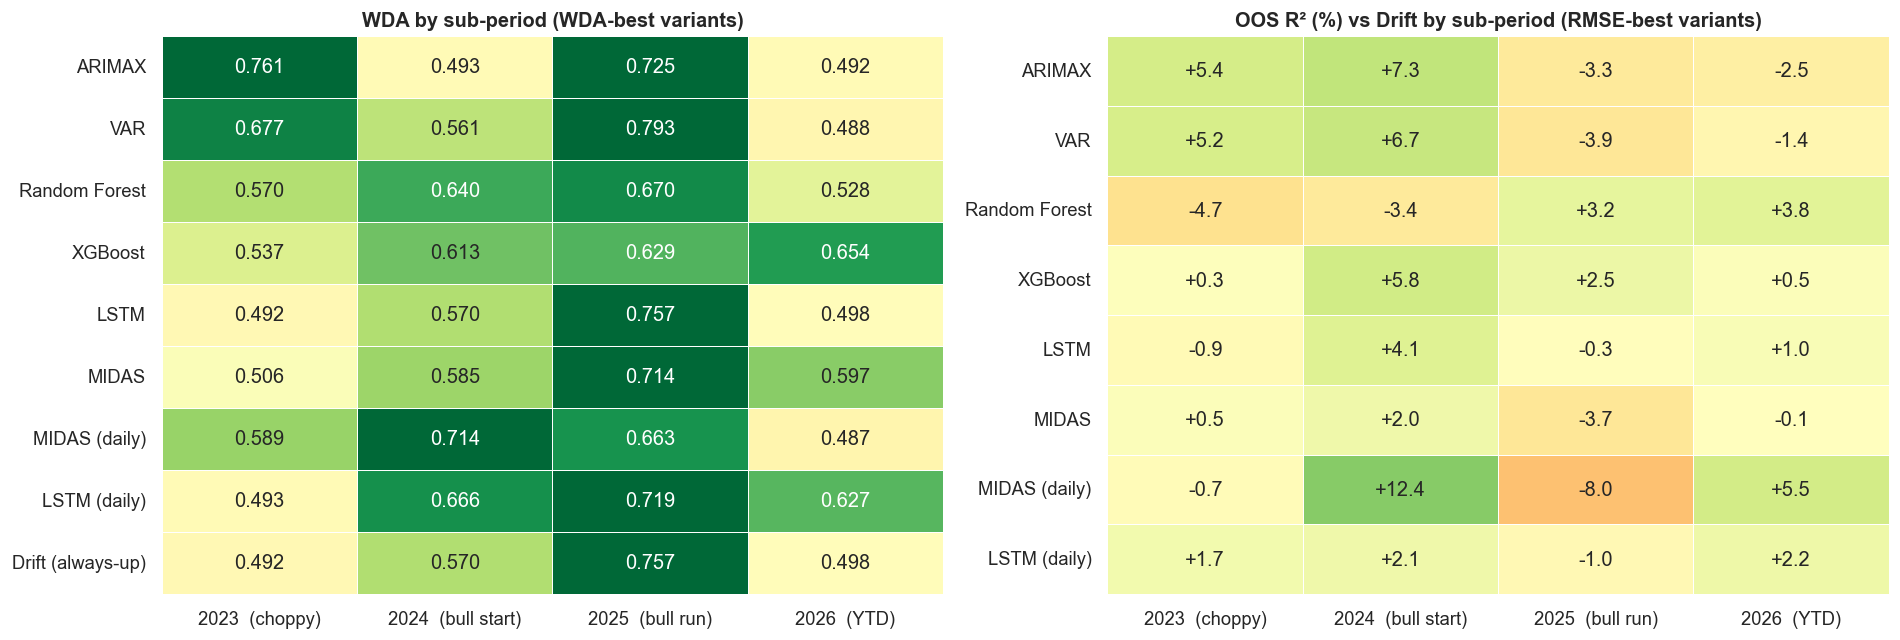

Consistency across sub-periods (lower Std = more stable):


,Full WDA,Mean (years),Std (years),Min (year),Max (year)
Model,,,,,
VAR,0.641,0.630,0.134,0.488,0.793
LSTM (daily),0.629,0.626,0.097,0.493,0.719
ARIMAX,0.628,0.618,0.145,0.492,0.761
MIDAS (daily),0.618,0.613,0.099,0.487,0.714
XGBoost,0.607,0.608,0.051,0.537,0.654
Random Forest,0.606,0.602,0.065,0.528,0.670
MIDAS,0.604,0.600,0.086,0.506,0.714
LSTM,0.588,0.579,0.124,0.492,0.757
Drift (always-up),0.588,0.579,0.124,0.492,0.757


In [12]:
year_cols = [lbl for lbl, (a, b) in PERIODS.items() if a == b]
FULL = '── Full test ──'

def per_period(pred_df, fn):
    out = {}
    for lbl, (a, b) in PERIODS.items():
        sub, dsub = pred_df.loc[a:b], drift_s.loc[a:b]
        out[lbl] = fn(sub['actual'].values, sub['predicted'].values, dsub.values)
    return out

def wda(a, p, d=None):
    hit = np.sign(a) == np.sign(p)
    return np.sum(np.abs(a) * hit) / np.sum(np.abs(a))

wda_matrix = pd.DataFrame({fam: per_period(df, wda)
                           for fam, df in best_preds['WDA-best'].items()}).T
wda_matrix.loc['Drift (always-up)'] = per_period(
    pd.DataFrame({'actual': test_ret.values, 'predicted': drift_s.values}, index=drift_s.index), wda)
r2_matrix = pd.DataFrame({fam: per_period(df, lambda a, p, d: oos_r2(a, p, d) * 100)
                          for fam, df in best_preds['RMSE-best'].items()}).T
wda_matrix.index.name = r2_matrix.index.name = 'Model'

fig, axes = plt.subplots(1, 2, figsize=(16, 5.5))
sns.heatmap(wda_matrix[year_cols], annot=True, fmt='.3f', cmap='RdYlGn',
            vmin=0.35, vmax=0.70, center=0.50, linewidths=0.5, ax=axes[0], cbar=False)
axes[0].set_title('WDA by sub-period (WDA-best variants)', fontweight='bold')
axes[0].set_ylabel('')
sns.heatmap(r2_matrix[year_cols], annot=True, fmt='+.1f', cmap='RdYlGn',
            center=0, vmin=-25, vmax=25, linewidths=0.5, ax=axes[1], cbar=False)
axes[1].set_title('OOS R² (%) vs Drift by sub-period (RMSE-best variants)', fontweight='bold')
axes[1].set_ylabel('')
plt.tight_layout()
fig.savefig('../images/returns_period.png', dpi=150, bbox_inches='tight')
plt.show()

consistency = pd.DataFrame({
    'Full WDA':     wda_matrix[FULL],
    'Mean (years)': wda_matrix[year_cols].mean(axis=1),
    'Std (years)':  wda_matrix[year_cols].std(axis=1),
    'Min (year)':   wda_matrix[year_cols].min(axis=1),
    'Max (year)':   wda_matrix[year_cols].max(axis=1),
}).sort_values('Full WDA', ascending=False)

print('Consistency across sub-periods (lower Std = more stable):')
display(consistency.style
        .format('{:.3f}')
        .background_gradient(cmap='RdYlGn', subset=['Full WDA', 'Mean (years)'], vmin=0.38, vmax=0.68)
        .background_gradient(cmap='RdYlGn_r', subset=['Std (years)'], vmin=0.0, vmax=0.15))